<a href="https://colab.research.google.com/github/kenzuroid-tech/PVCK_Ganjil_2026/blob/main/Week5_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Siti Nikmatus Sholihah'
NIM = '244107020014' # ganti dengan NIM Anda

N = int(NIM[-3:])
PARAM = {
 'bins' : 2 ** ((N % 4) + 3),
 'clip' : round(1.0 + (N % 5) * 0.5, 1),
 'tile' : (N % 4) + 2,
 'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
 print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Siti Nikmatus Sholihah
NIM : 244107020014 | N = 14
bins   : 32
clip   : 3.0
tile   : 4
L      : 8
WAKTU : 2026-09-29 22:29:42 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 47a2d21d9d14ad0c


**Praktikum E1**

1. 1.	Buka https://colab.research.google.com/. Setelah dipastikan bahwa Google Colab terhubung dengan akun GitHub, lanjutkan dengan memilih repository yang telah digunakan pada praktikum minggu lalu, lalu ubah nama berkas menjadi "Week5_25.ipynb".

Kemudian import folder yang ada di Drive Anda dengan cara sebagai berikut.

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2.	Import beberapa library berikut yang akan digunakan selama uji coba praktikum minggu ke-5 berikut.

In [31]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

3.	Membuat histogram citra berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra contoh lena.jpg dan cocokkan keluarannya dengan gambar contoh pada modul; setelah cocok, tahap 2 ulangi dengan citra KTM1b.jpg milik Anda sendiri.

<BarContainer object of 256 artists>

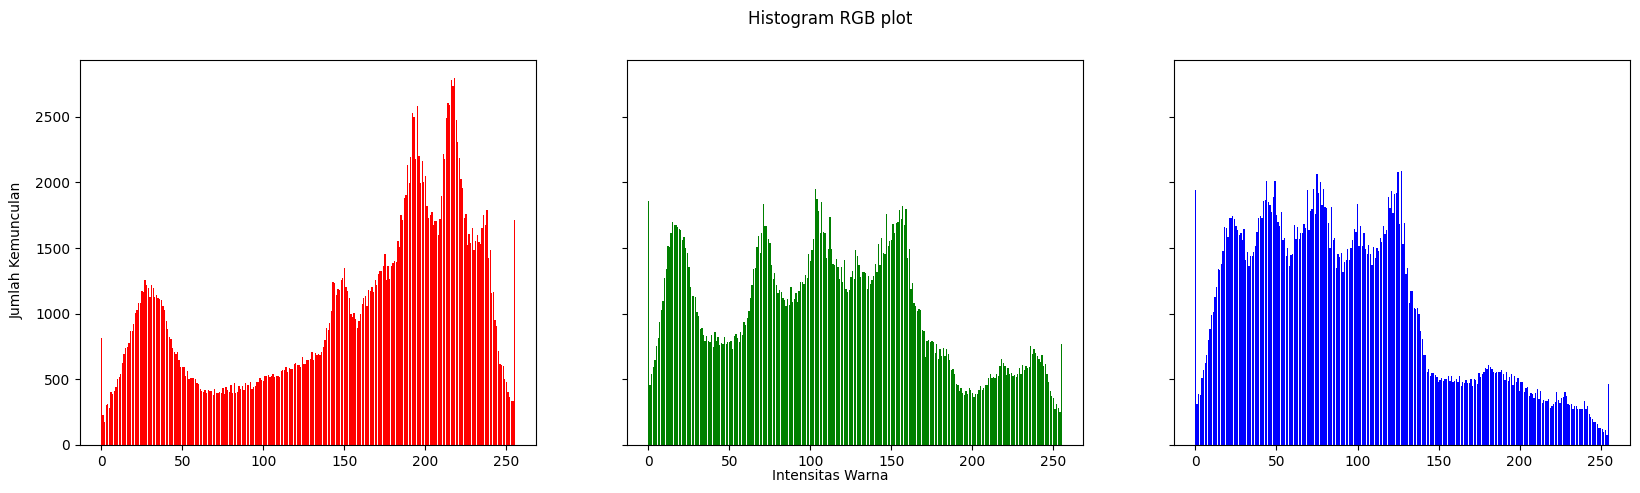

In [32]:
img = cv.imread('/content/drive/MyDrive/PVCK/GAMBAR/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height) :
  for x in range(0, width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')


**Pertanyaan Praktikum 1**

1.	Buatlah histogram citra yang sama menggunakan library NumPy, yaitu numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

=== LENA.JPG ===
Selisih Manual vs NumPy
Red   : 0
Green : 0
Blue  : 0

Selisih Manual vs cv.calcHist
Red   : 0.0
Green : 0.0
Blue  : 0.0

Selisih Maksimum Ketiganya : 0


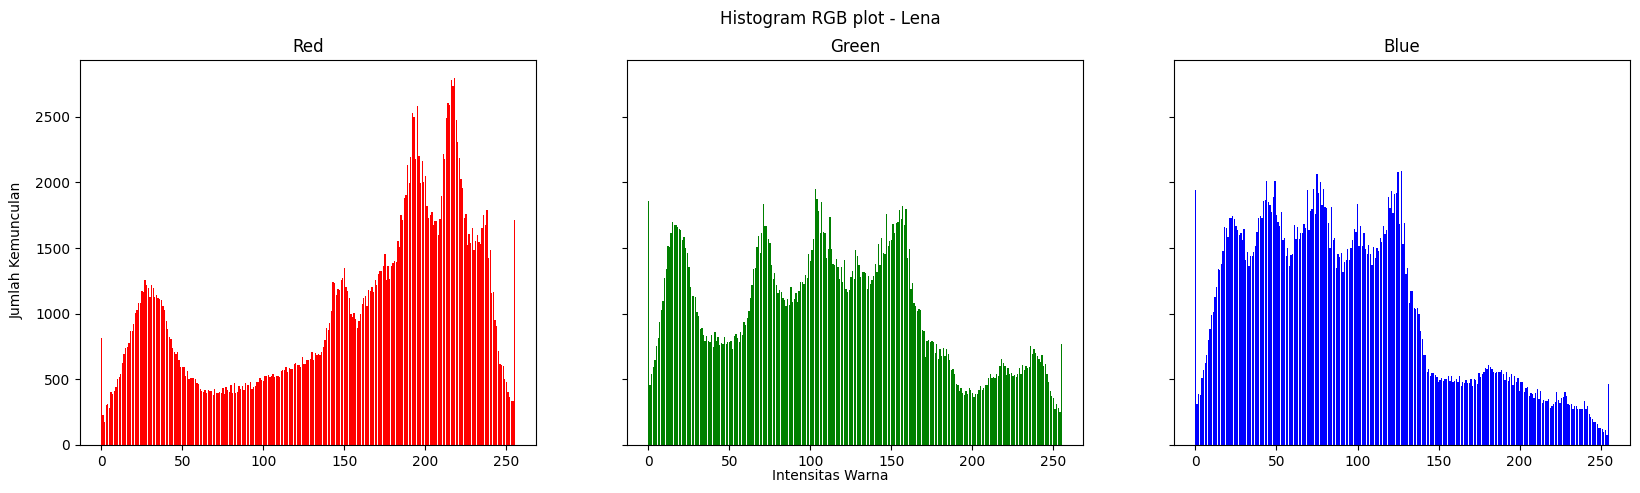

In [33]:
# 1A. Gambar Lena.jpg
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/PVCK/GAMBAR/lena.jpg')

img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)

names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
  for x in range(0, width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

# Histogram menggunakan numpy.histogram
red_np, _ = np.histogram(img[:, :, 0], bins=256, range=(0, 256))
green_np, _ = np.histogram(img[:, :, 1], bins=256, range=(0, 256))
blue_np, _ = np.histogram(img[:, :, 2], bins=256, range=(0, 256))

# Histogram menggunakan cv.calcHist
red_cv = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()
green_cv = cv.calcHist([img], [1], None, [256], [0, 256]).flatten()
blue_cv = cv.calcHist([img], [2], None, [256], [0, 256]).flatten()

# Menghitung selisih maksimum
diff_red_np = np.max(np.abs(np.array(red) - red_np))
diff_green_np = np.max(np.abs(np.array(green) - green_np))
diff_blue_np = np.max(np.abs(np.array(blue) - blue_np))

diff_red_cv = np.max(np.abs(np.array(red) - red_cv))
diff_green_cv = np.max(np.abs(np.array(green) - green_cv))
diff_blue_cv = np.max(np.abs(np.array(blue) - blue_cv))

print("=== LENA.JPG ===")

print("Selisih Manual vs NumPy")
print("Red   :", diff_red_np)
print("Green :", diff_green_np)
print("Blue  :", diff_blue_np)

print("\nSelisih Manual vs cv.calcHist")
print("Red   :", diff_red_cv)
print("Green :", diff_green_cv)
print("Blue  :", diff_blue_cv)

print("\nSelisih Maksimum Ketiganya :",
      max(diff_red_np, diff_green_np, diff_blue_np,
          diff_red_cv, diff_green_cv, diff_blue_cv))

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)

fig.suptitle('Histogram RGB plot - Lena')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red, color='red')
axs[0].set_title('Red')

axs[1].bar(names, green, color='green')
axs[1].set_title('Green')

axs[2].bar(names, blue, color='blue')
axs[2].set_title('Blue')

plt.show()

=== KTM1B.JPG ===
Selisih Manual vs NumPy
Red   : 0
Green : 0
Blue  : 0

Selisih Manual vs cv.calcHist
Red   : 0.0
Green : 0.0
Blue  : 0.0

Selisih Maksimum Ketiganya : 0


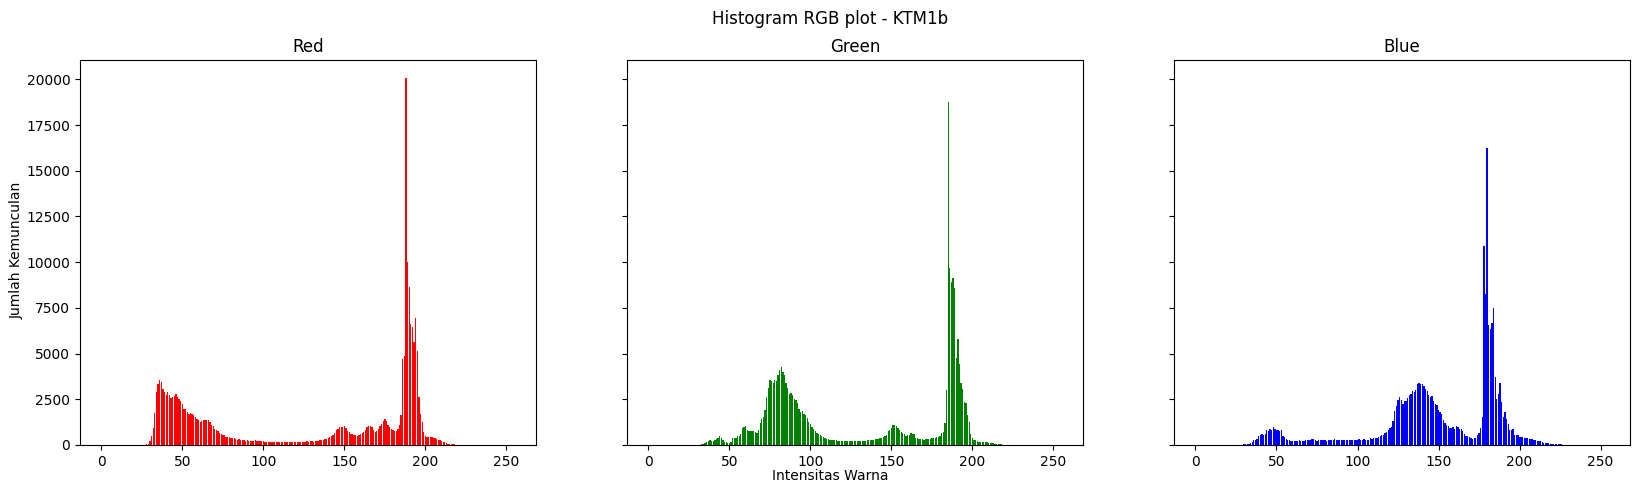

In [34]:
# 1B. Gambar KTM1b.jpg
img = cv.imread('/content/drive/MyDrive/PVCK/GAMBAR/KTM1b.jpg')

img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)

names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
  for x in range(0, width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

# Histogram menggunakan numpy.histogram
red_np, _ = np.histogram(img[:, :, 0], bins=256, range=(0, 256))
green_np, _ = np.histogram(img[:, :, 1], bins=256, range=(0, 256))
blue_np, _ = np.histogram(img[:, :, 2], bins=256, range=(0, 256))

# Histogram menggunakan cv.calcHist
red_cv = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()
green_cv = cv.calcHist([img], [1], None, [256], [0, 256]).flatten()
blue_cv = cv.calcHist([img], [2], None, [256], [0, 256]).flatten()

# Menghitung selisih maksimum
diff_red_np = np.max(np.abs(np.array(red) - red_np))
diff_green_np = np.max(np.abs(np.array(green) - green_np))
diff_blue_np = np.max(np.abs(np.array(blue) - blue_np))

diff_red_cv = np.max(np.abs(np.array(red) - red_cv))
diff_green_cv = np.max(np.abs(np.array(green) - green_cv))
diff_blue_cv = np.max(np.abs(np.array(blue) - blue_cv))

print("=== KTM1B.JPG ===")

print("Selisih Manual vs NumPy")
print("Red   :", diff_red_np)
print("Green :", diff_green_np)
print("Blue  :", diff_blue_np)

print("\nSelisih Manual vs cv.calcHist")
print("Red   :", diff_red_cv)
print("Green :", diff_green_cv)
print("Blue  :", diff_blue_cv)

print("\nSelisih Maksimum Ketiganya :",
      max(diff_red_np, diff_green_np, diff_blue_np,
          diff_red_cv, diff_green_cv, diff_blue_cv))

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)

fig.suptitle('Histogram RGB plot - KTM1b')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red, color='red')
axs[0].set_title('Red')

axs[1].bar(names, green, color='green')
axs[1].set_title('Green')

axs[2].bar(names, blue, color='blue')
axs[2].set_title('Blue')

plt.show()

2.	Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi pencahayaan saat akuisisi pada Pertemuan 2.

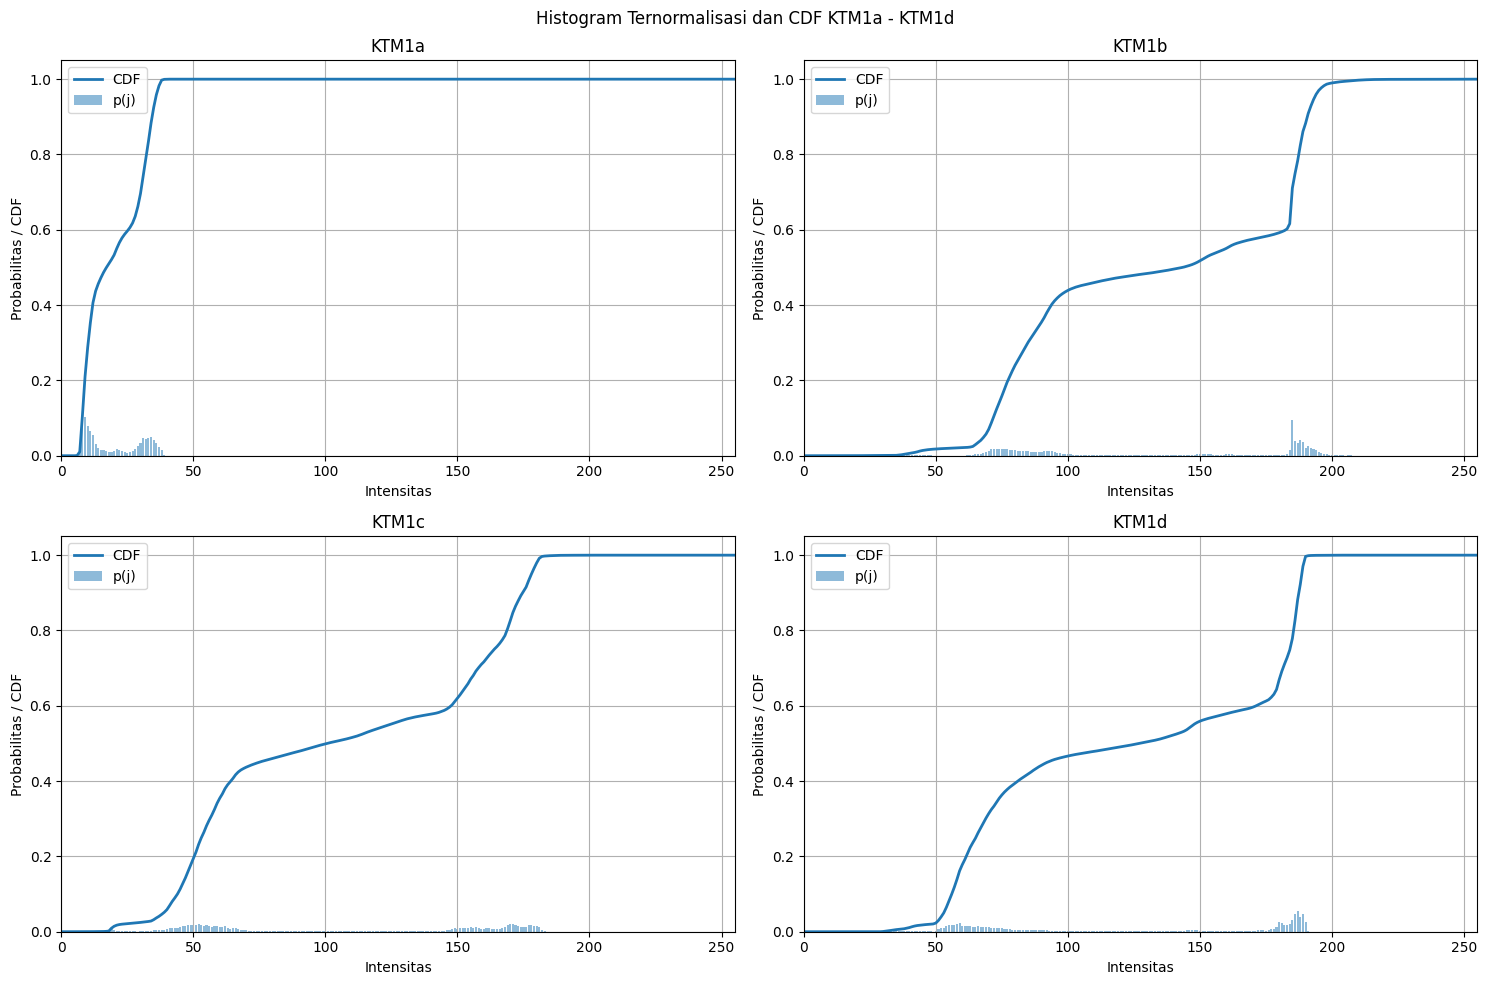

In [35]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca 4 citra
images = [
    cv.imread('/content/drive/MyDrive/PVCK/GAMBAR/KTM1a.jpg'),
    cv.imread('/content/drive/MyDrive/PVCK/GAMBAR/KTM1b.jpg'),
    cv.imread('/content/drive/MyDrive/PVCK/GAMBAR/KTM1c.jpg'),
    cv.imread('/content/drive/MyDrive/PVCK/GAMBAR/KTM1d.jpg')
]

names = ['KTM1a', 'KTM1b', 'KTM1c', 'KTM1d']

fig, axs = plt.subplots(2, 2, figsize=[15, 10])

fig.suptitle('Histogram Ternormalisasi dan CDF KTM1a - KTM1d')

for i in range(4):

  # Mengubah citra menjadi grayscale
  img = cv.cvtColor(images[i], cv.COLOR_BGR2GRAY)

  # Histogram
  hist = cv.calcHist([img], [0], None, [256], [0, 256])

  # Histogram ternormalisasi p(j)
  p = hist / (img.shape[0] * img.shape[1])

  # CDF
  cdf = np.cumsum(p)

  # Intensitas 0 - 255
  names_intensity = np.arange(256)

  # Menentukan posisi subplot
  ax = axs[i // 2, i % 2]

  # Histogram ternormalisasi
  ax.bar(names_intensity, p.flatten(), alpha=0.5, label='p(j)')

  # Kurva CDF
  ax.plot(names_intensity, cdf.flatten(), linewidth=2, label='CDF')

  ax.set_title(names[i])
  ax.set_xlabel('Intensitas')
  ax.set_ylabel('Probabilitas / CDF')
  ax.set_xlim(0, 255)
  ax.set_ylim(0, 1.05)
  ax.legend()
  ax.grid()

plt.tight_layout()
plt.show()

3.	Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan 256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang ketika jumlah bin dikurangi.

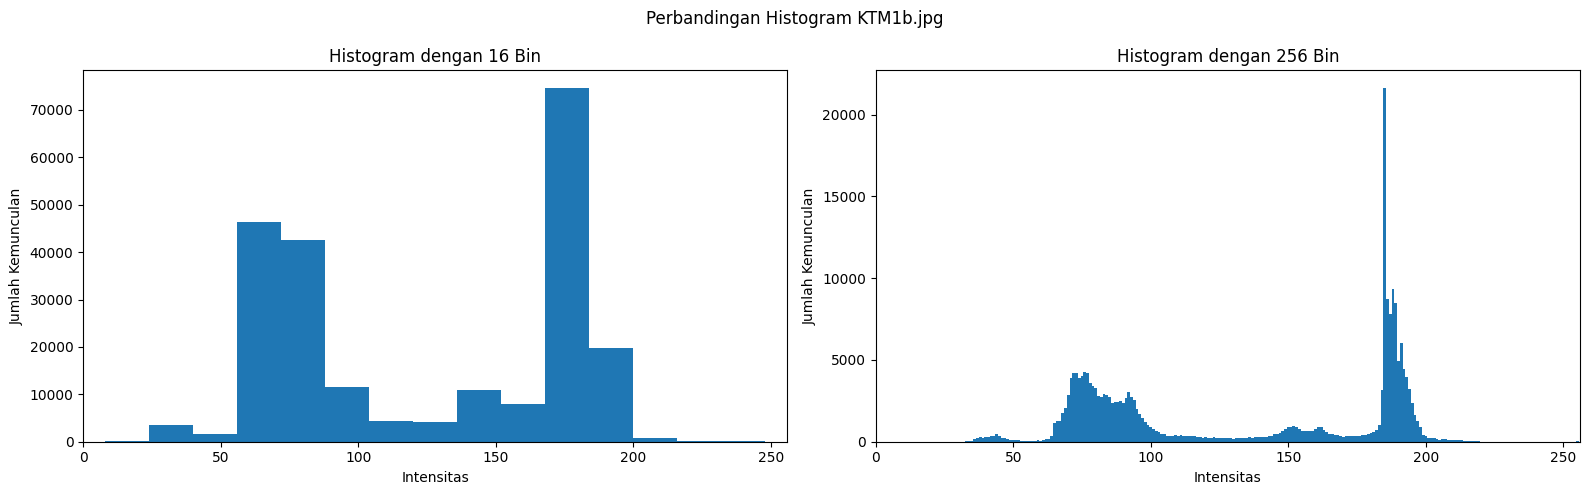

In [36]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

PARAM = {
    'bins': 16
}

img = cv.imread('/content/drive/MyDrive/PVCK/GAMBAR/KTM1b.jpg')

img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Histogram dengan jumlah bin = PARAM['bins']
hist_bins, bins_bins = np.histogram(
    img,
    bins=PARAM['bins'],
    range=(0, 256)
)

# Histogram dengan 256 bin
hist_256, bins_256 = np.histogram(
    img,
    bins=256,
    range=(0, 256)
)

# Menampilkan histogram berdampingan
fig, axs = plt.subplots(1, 2, figsize=[16, 5])

fig.suptitle('Perbandingan Histogram KTM1b.jpg')

# Histogram PARAM['bins']
axs[0].bar(
    bins_bins[:-1],
    hist_bins,
    width=256/PARAM['bins']
)

axs[0].set_title('Histogram dengan ' + str(PARAM['bins']) + ' Bin')
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Jumlah Kemunculan')
axs[0].set_xlim(0, 256)

# Histogram 256 bin
axs[1].bar(
    bins_256[:-1],
    hist_256,
    width=1
)

axs[1].set_title('Histogram dengan 256 Bin')
axs[1].set_xlabel('Intensitas')
axs[1].set_ylabel('Jumlah Kemunculan')
axs[1].set_xlim(0, 256)

plt.tight_layout()
plt.show()

**Percobaan 2**

1. Buatlah histogram equalization beserta tampilan citra sebelum dan sesudah proses, berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra contoh lena_lc.jpg dan cocokkan hasilnya dengan gambar contoh pada modul; tahap 2 ulangi pada citra KTM1a.jpg milik Anda, yaitu hasil akuisisi di ruangan gelap.

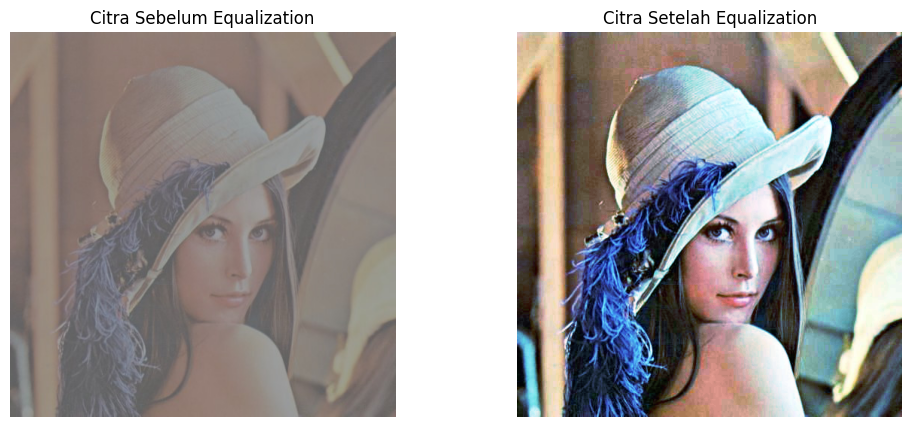

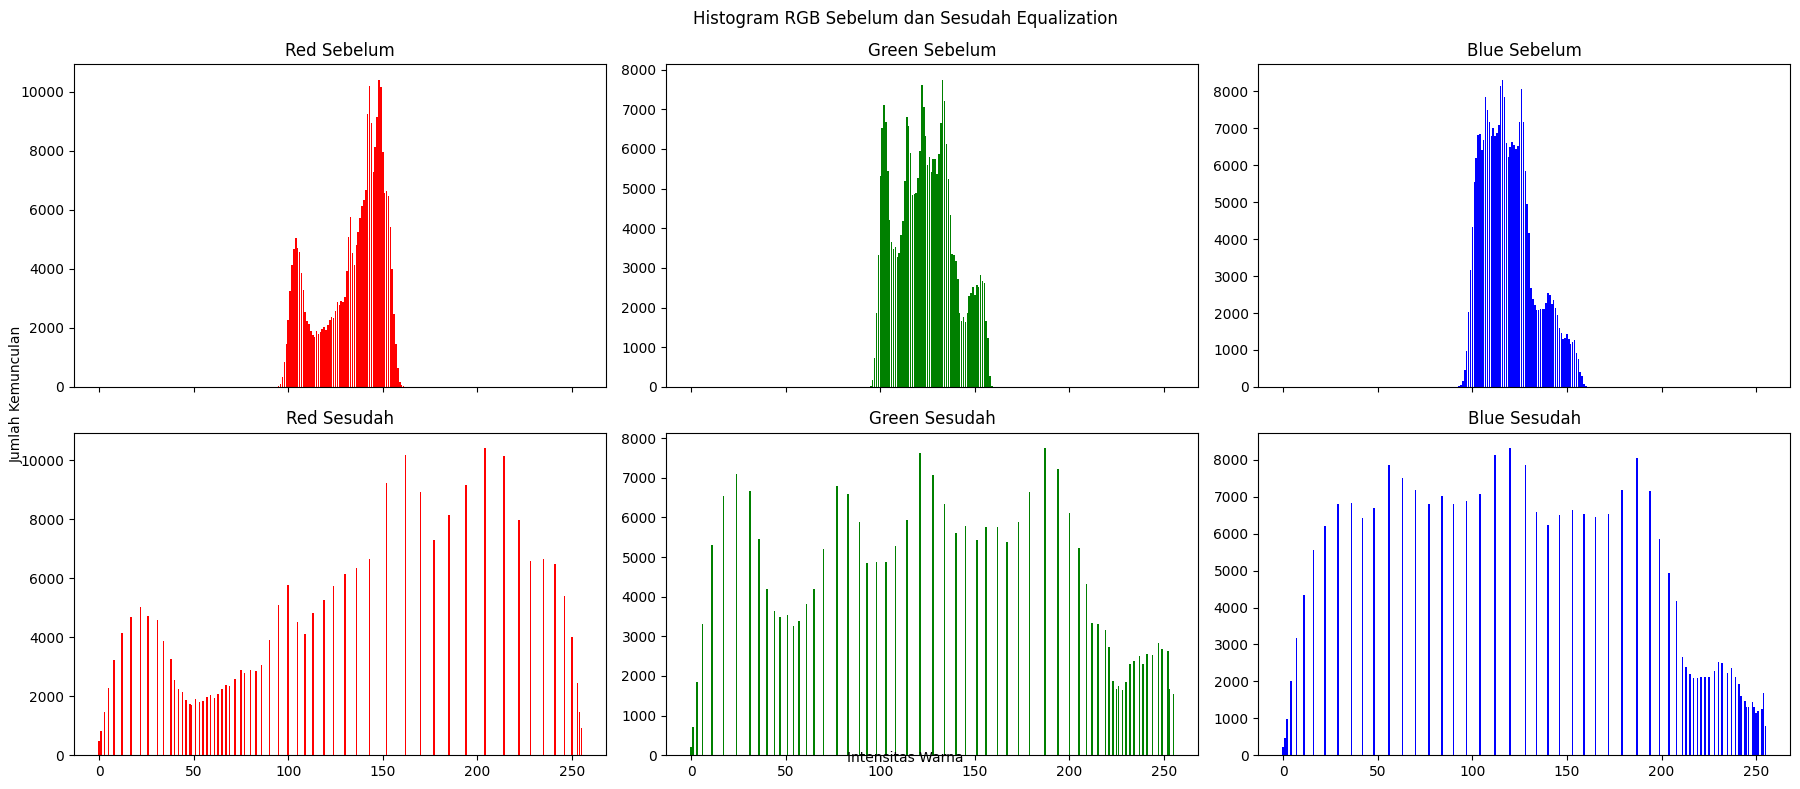

In [49]:
# Tahap 1

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Input image
img = cv.imread('/content/drive/MyDrive/PVCK/GAMBAR/lena_lc.jpg')

# BGR menjadi RGB
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)

# Jumlah pixel
total_pixel = height * width

# Menyiapkan histogram RGB
red = [0] * 256
green = [0] * 256
blue = [0] * 256

# Menghitung jumlah kemunculan setiap intensitas
for y in range(0, height):
  for x in range(0, width):

    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

# HISTOGRAM EQUALIZATION CHANNEL RED

# Frekuensi kumulatif
red_cdf = np.cumsum(red)

# Normalisasi CDF
red_cdf_normal = red_cdf / total_pixel

# Rumus K = CDF * (L-1)
red_k = np.round(red_cdf_normal * 255).astype(np.uint8)

# HISTOGRAM EQUALIZATION CHANNEL GREEN

green_cdf = np.cumsum(green)
green_cdf_normal = green_cdf / total_pixel
green_k = np.round(green_cdf_normal * 255).astype(np.uint8)

# HISTOGRAM EQUALIZATION CHANNEL BLUE

blue_cdf = np.cumsum(blue)
blue_cdf_normal = blue_cdf / total_pixel
blue_k = np.round(blue_cdf_normal * 255).astype(np.uint8)

# TRANSFORMASI CITRA

img_equalized = img.copy()

for y in range(0, height):
  for x in range(0, width):
    img_equalized[y][x][0] = red_k[img[y][x][0]]
    img_equalized[y][x][1] = green_k[img[y][x][1]]
    img_equalized[y][x][2] = blue_k[img[y][x][2]]

# HISTOGRAM HASIL EQUALIZATION

red_eq = [0] * 256
green_eq = [0] * 256
blue_eq = [0] * 256

for y in range(0, height):
  for x in range(0, width):
    red_eq[img_equalized[y][x][0]] += 1
    green_eq[img_equalized[y][x][1]] += 1
    blue_eq[img_equalized[y][x][2]] += 1

# MENAMPILKAN CITRA

fig, axs = plt.subplots(1, 2, figsize=[12, 5])
axs[0].imshow(img)
axs[0].set_title('Citra Sebelum Equalization')
axs[0].axis('off')
axs[1].imshow(img_equalized)
axs[1].set_title('Citra Setelah Equalization')
axs[1].axis('off')
plt.show()

# MENAMPILKAN HISTOGRAM

names = np.arange(256)
fig, axs = plt.subplots(2, 3, figsize=[18, 8], sharex=True)
fig.suptitle('Histogram RGB Sebelum dan Sesudah Equalization')

# Sebelum
axs[0][0].bar(names, red, color='red')
axs[0][0].set_title('Red Sebelum')
axs[0][1].bar(names, green, color='green')
axs[0][1].set_title('Green Sebelum')
axs[0][2].bar(names, blue, color='blue')
axs[0][2].set_title('Blue Sebelum')

# Sesudah
axs[1][0].bar(names, red_eq, color='red')
axs[1][0].set_title('Red Sesudah')
axs[1][1].bar(names, green_eq, color='green')
axs[1][1].set_title('Green Sesudah')
axs[1][2].bar(names, blue_eq, color='blue')
axs[1][2].set_title('Blue Sesudah')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
fig.text(0.0025, 0.5, 'Jumlah Kemunculan',
         va='center', rotation='vertical')
plt.tight_layout()
plt.show()

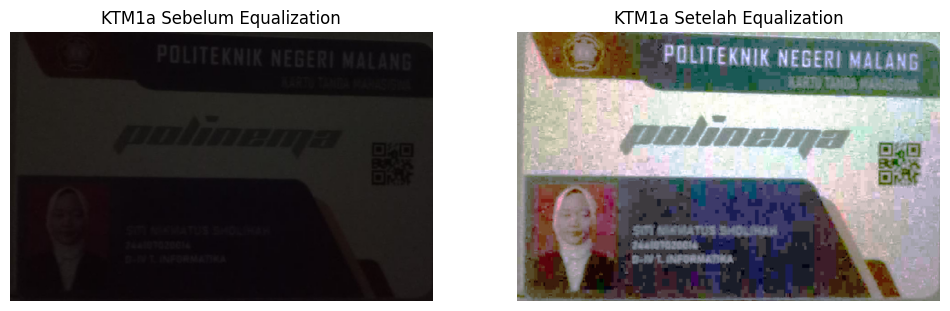

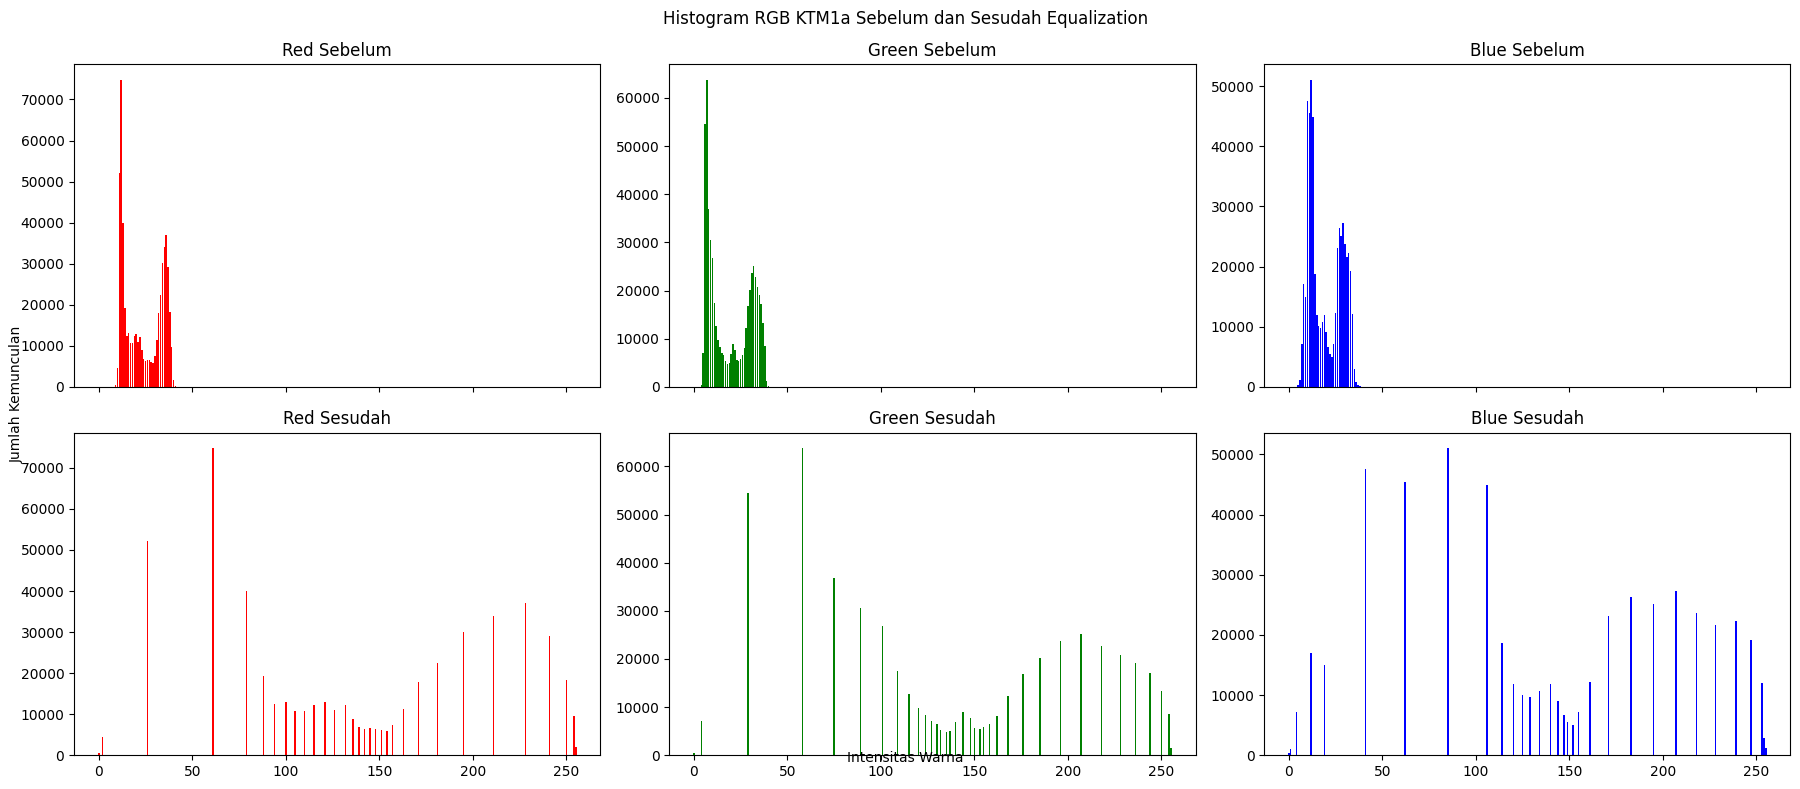

In [48]:
# Tahap 2

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Input image
img = cv.imread('/content/drive/MyDrive/PVCK/GAMBAR/KTM1a.jpg')

# BGR menjadi RGB
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)

total_pixel = height * width

# Histogram awal
red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(0, height):
  for x in range(0, width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

# CDF RED

red_cdf = np.cumsum(red)
red_cdf_normal = red_cdf / total_pixel
red_k = np.round(red_cdf_normal * 255).astype(np.uint8)

# CDF GREEN

green_cdf = np.cumsum(green)
green_cdf_normal = green_cdf / total_pixel
green_k = np.round(green_cdf_normal * 255).astype(np.uint8)

# CDF BLUE

blue_cdf = np.cumsum(blue)
blue_cdf_normal = blue_cdf / total_pixel
blue_k = np.round(blue_cdf_normal * 255).astype(np.uint8)

# TRANSFORMASI CITRA

img_equalized = img.copy()

for y in range(0, height):
  for x in range(0, width):
    img_equalized[y][x][0] = red_k[img[y][x][0]]
    img_equalized[y][x][1] = green_k[img[y][x][1]]
    img_equalized[y][x][2] = blue_k[img[y][x][2]]

# HISTOGRAM HASIL

red_eq = [0] * 256
green_eq = [0] * 256
blue_eq = [0] * 256

for y in range(0, height):
  for x in range(0, width):
    red_eq[img_equalized[y][x][0]] += 1
    green_eq[img_equalized[y][x][1]] += 1
    blue_eq[img_equalized[y][x][2]] += 1

# CITRA SEBELUM DAN SESUDAH

fig, axs = plt.subplots(1, 2, figsize=[12, 5])
axs[0].imshow(img)
axs[0].set_title('KTM1a Sebelum Equalization')
axs[0].axis('off')
axs[1].imshow(img_equalized)
axs[1].set_title('KTM1a Setelah Equalization')
axs[1].axis('off')
plt.show()

# HISTOGRAM

names = np.arange(256)
fig, axs = plt.subplots(2, 3, figsize=[18, 8], sharex=True)
fig.suptitle('Histogram RGB KTM1a Sebelum dan Sesudah Equalization')

# Sebelum
axs[0][0].bar(names, red, color='red')
axs[0][0].set_title('Red Sebelum')
axs[0][1].bar(names, green, color='green')
axs[0][1].set_title('Green Sebelum')
axs[0][2].bar(names, blue, color='blue')
axs[0][2].set_title('Blue Sebelum')

# Sesudah
axs[1][0].bar(names, red_eq, color='red')
axs[1][0].set_title('Red Sesudah')
axs[1][1].bar(names, green_eq, color='green')
axs[1][1].set_title('Green Sesudah')
axs[1][2].bar(names, blue_eq, color='blue')
axs[1][2].set_title('Blue Sesudah')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
fig.text(0.0025, 0.5, 'Jumlah Kemunculan',
         va='center', rotation='vertical')
plt.tight_layout()
plt.show()

2. Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist”

In [50]:
def histogram_equalization_manual(channel):

  height, width = channel.shape

  total_pixel = height * width

  # Histogram
  hist = [0] * 256

  for y in range(0, height):
    for x in range(0, width):
      hist[channel[y][x]] += 1

  # Frekuensi kumulatif
  cdf = np.cumsum(hist)

  # Normalisasi CDF
  cdf_normal = cdf / total_pixel

  # Rumus K = CDF * (L-1)
  K = np.round(cdf_normal * 255).astype(np.uint8)

  # Transformasi citra
  hasil = np.zeros_like(channel)

  for y in range(0, height):
    for x in range(0, width):
      hasil[y][x] = K[channel[y][x]]
  return hasil

Selisih maksimum manual vs cv.equalizeHist (lena_lc.jpg): 0


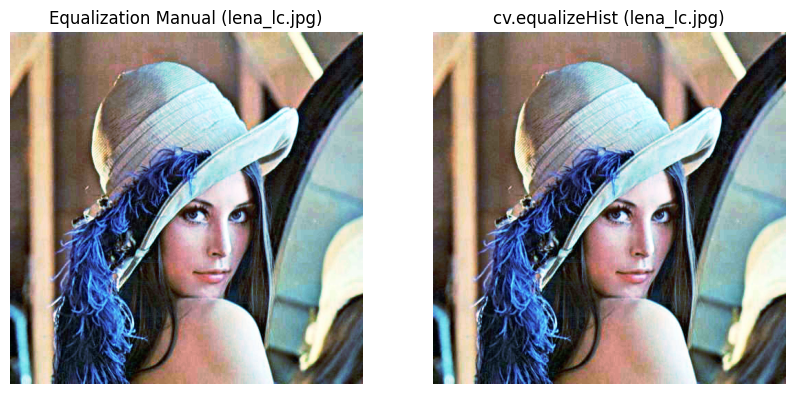

In [51]:
# lena_lc.jpg

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# FUNGSI HISTOGRAM EQUALIZATION MANUAL

def histogram_equalization_manual(channel):
  height, width = channel.shape
  total_pixel = height * width

  # Histogram
  hist = [0] * 256
  for y in range(0, height):
    for x in range(0, width):
      hist[channel[y][x]] += 1

  # Frekuensi kumulatif
  cdf = np.cumsum(hist)

  # Normalisasi CDF
  cdf_normal = cdf / total_pixel

  # Rumus K = CDF * (L-1)
  K = np.round(cdf_normal * 255).astype(np.uint8)

  # Transformasi citra
  hasil = np.zeros_like(channel)
  for y in range(0, height):
    for x in range(0, width):
      hasil[y][x] = K[channel[y][x]]
  return hasil

# INPUT LENA

bgr = cv.imread(
    '/content/drive/MyDrive/PVCK/GAMBAR/lena_lc.jpg'
)

# EQUALIZATION MANUAL

b, g, r = cv.split(bgr)
b_eq = histogram_equalization_manual(b)
g_eq = histogram_equalization_manual(g)
r_eq = histogram_equalization_manual(r)
hasil_eq = cv.merge([b_eq, g_eq, r_eq])

# EQUALIZATION MENGGUNAKAN CV2

b, g, r = cv.split(bgr)
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)
hasil_cv = cv.merge([
    b_equalized,
    g_equalized,
    r_equalized
])

# MENGHITUNG SELISIH MAKSIMUM

selisih = np.max(
    np.abs(
        hasil_eq.astype(np.int16) -
        hasil_cv.astype(np.int16)
    )
)
print(
    'Selisih maksimum manual vs cv.equalizeHist '
    '(lena_lc.jpg):',
    selisih
)

# MENAMPILKAN HASIL

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(
    cv.cvtColor(hasil_eq, cv.COLOR_BGR2RGB)
)
plt.title('Equalization Manual (lena_lc.jpg)')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(
    cv.cvtColor(hasil_cv, cv.COLOR_BGR2RGB)
)
plt.title('cv.equalizeHist (lena_lc.jpg)')
plt.axis('off')
plt.show()

Selisih maksimum manual vs cv.equalizeHist (KTM1a.jpg): 0


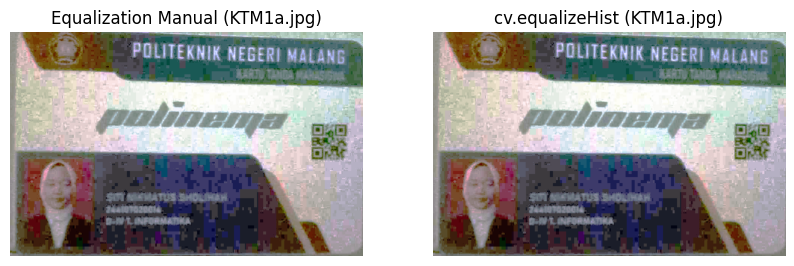

In [52]:
# KTM1a.jpg

bgr = cv.imread(
    '/content/drive/MyDrive/PVCK/GAMBAR/KTM1a.jpg'
)

# EQUALIZATION MANUAL

b, g, r = cv.split(bgr)
b_eq = histogram_equalization_manual(b)
g_eq = histogram_equalization_manual(g)
r_eq = histogram_equalization_manual(r)
hasil_eq = cv.merge([b_eq, g_eq, r_eq])

# EQUALIZATION CV2

b, g, r = cv.split(bgr)
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

hasil_cv = cv.merge([
    b_equalized,
    g_equalized,
    r_equalized
])

# SELISIH MAKSIMUM

selisih = np.max(
    np.abs(
        hasil_eq.astype(np.int16) -
        hasil_cv.astype(np.int16)
    )
)
print(
    'Selisih maksimum manual vs cv.equalizeHist '
    '(KTM1a.jpg):',
    selisih
)

# MENAMPILKAN HASIL

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(
    cv.cvtColor(hasil_eq, cv.COLOR_BGR2RGB)
)
plt.title('Equalization Manual (KTM1a.jpg)')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(
    cv.cvtColor(hasil_cv, cv.COLOR_BGR2RGB)
)
plt.title('cv.equalizeHist (KTM1a.jpg)')
plt.axis('off')
plt.show()

3. Ekualisasi juga dapat diterapkan pada citra berwarna. Cara yang biasanya pertama kali terpikirkan adalah mengekualisasi kanal biru, hijau, dan merah satu per satu. Jalankan potongan kode berikut pada citra contoh lena.jpg terlebih dulu, kemudian ulangi pada KTM1d.jpg milik Anda, dan amati warna yang dihasilkan pada keduanya.

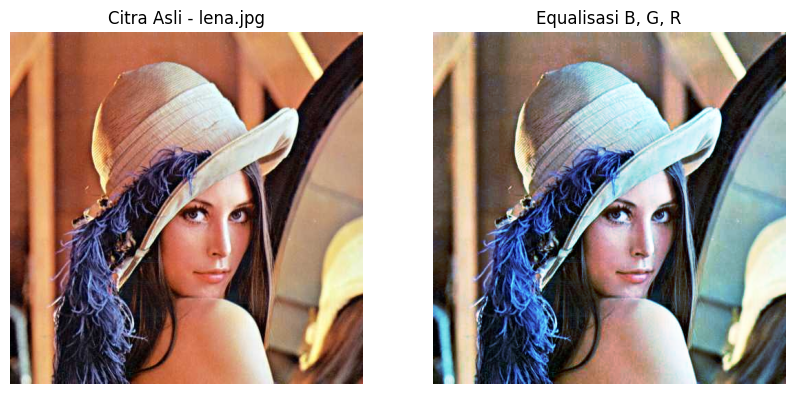

In [53]:
# lena.jpg

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

berkas = '/content/drive/MyDrive/PVCK/GAMBAR/lena.jpg'

bgr = cv.imread(berkas)

# Tiap kanal diequalisasi sendiri-sendiri

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
ho_rgb = cv.merge(kanal)

# MENAMPILKAN HASIL

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title('Citra Asli - lena.jpg')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(ho_rgb, cv.COLOR_BGR2RGB))
plt.title('Equalisasi B, G, R')
plt.axis('off')
plt.show()

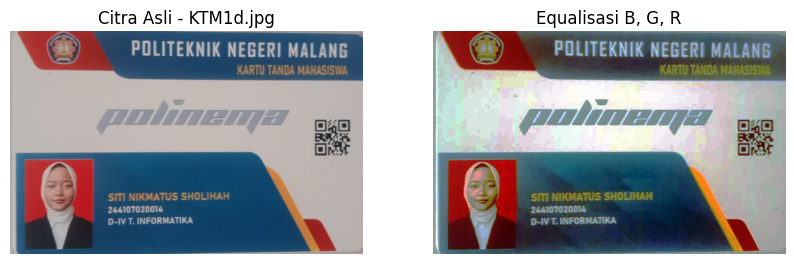

In [54]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

berkas = '/content/drive/MyDrive/PVCK/GAMBAR/KTM1d.jpg'

bgr = cv.imread(berkas)

# Tiap kanal diequalisasi sendiri-sendiri

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
ho_rgb = cv.merge(kanal)

# MENAMPILKAN HASIL

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title('Citra Asli - KTM1d.jpg')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(ho_rgb, cv.COLOR_BGR2RGB))
plt.title('Equalisasi B, G, R')
plt.axis('off')
plt.show()

4. Cara kedua memisahkan kecerahan dari informasi warna. Citra diubah ke ruang warna YCrCb, hanya kanal Y yang diekualisasi, lalu dikembalikan ke BGR. Kanal Cr dan Cb yang menyimpan informasi warna tidak disentuh sama sekali. Kanal V pada HSV dan kanal L pada LAB berperan serupa, sehingga ketiganya dicoba sekaligus. (gunakan KTM1d.jpg)

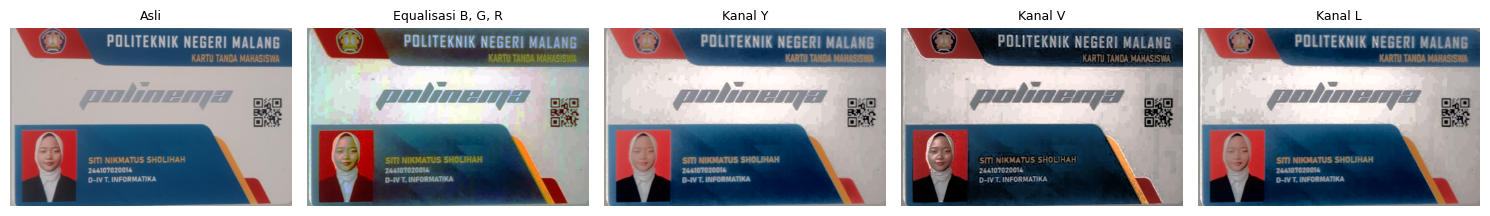

In [28]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

berkas = '/content/drive/MyDrive/PVCK/GAMBAR/KTM1d.jpg'

bgr = cv.imread(berkas)

# CARA 2A - YCrCb
# Hanya channel Y yang diequalisasi

ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
ho_y = cv.cvtColor(
    cv.merge([
        cv.equalizeHist(y),
        cr,
        cb
    ]),
    cv.COLOR_YCrCb2BGR
)

# CARA 2B - HSV
# Hanya channel V yang diequalisasi

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
ho_v = cv.cvtColor(
    cv.merge([
        h,
        sat,
        cv.equalizeHist(v)
    ]),
    cv.COLOR_HSV2BGR
)

# CARA 2C - LAB
# Hanya channel L yang diequalisasi

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
ho_l = cv.cvtColor(
    cv.merge([
        cv.equalizeHist(l),
        a,
        b
    ]),
    cv.COLOR_LAB2BGR
)

# MENAMPILKAN SEMUA HASIL

judul = [
    'Asli',
    'Equalisasi B, G, R',
    'Kanal Y',
    'Kanal V',
    'Kanal L'
]

citra = [
    bgr,
    cv.merge([
        cv.equalizeHist(cv.split(bgr)[0]),
        cv.equalizeHist(cv.split(bgr)[1]),
        cv.equalizeHist(cv.split(bgr)[2])
    ]),
    ho_y,
    ho_v,
    ho_l
]


plt.figure(figsize=(15, 4))

for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(t, fontsize=9)
    plt.axis('off')
plt.tight_layout()

plt.show()

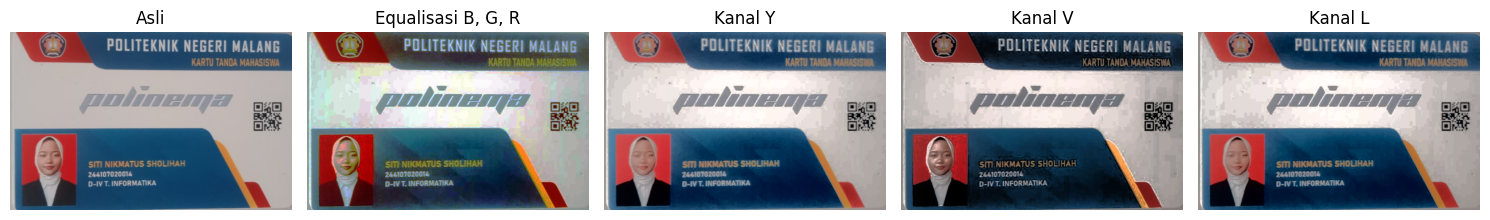

In [57]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

berkas = '/content/drive/MyDrive/PVCK/GAMBAR/KTM1d.jpg'

bgr = cv.imread(berkas)

# EQUALISASI B, G, R

b, g, r = cv.split(bgr)
b_eq = cv.equalizeHist(b)
g_eq = cv.equalizeHist(g)
r_eq = cv.equalizeHist(r)
ho_rgb = cv.merge([b_eq, g_eq, r_eq])

# KANAL Y

ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
y_eq = cv.equalizeHist(y)
ho_y = cv.cvtColor(
    cv.merge([y_eq, cr, cb]),
    cv.COLOR_YCrCb2BGR
)

# KANAL V

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
v_eq = cv.equalizeHist(v)
ho_v = cv.cvtColor(
    cv.merge([h, sat, v_eq]),
    cv.COLOR_HSV2BGR
)

# KANAL L

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
l_eq = cv.equalizeHist(l)
ho_l = cv.cvtColor(
    cv.merge([l_eq, a, b]),
    cv.COLOR_LAB2BGR
)

# TAMPILKAN HASIL

judul = ['Asli', 'Equalisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, ho_rgb, ho_y, ho_v, ho_l]
plt.figure(figsize=(15, 4))

for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(t)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [58]:
# PERGESERAN HUE

def hitung_hue_shift(asli, hasil):
    hsv_asli = cv.cvtColor(asli, cv.COLOR_BGR2HSV)
    hsv_hasil = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)
    h1 = hsv_asli[:, :, 0].astype(np.int16)
    h2 = hsv_hasil[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

hue_rgb = hitung_hue_shift(bgr, ho_rgb)
hue_y = hitung_hue_shift(bgr, ho_y)
hue_v = hitung_hue_shift(bgr, ho_v)
hue_l = hitung_hue_shift(bgr, ho_l)

print('B, G, R :', hue_rgb)
print('Y       :', hue_y)
print('V       :', hue_v)
print('L       :', hue_l)

# RATA-RATA KECERAHAN

def rata_kecerahan(citra):
    hsv = cv.cvtColor(citra, cv.COLOR_BGR2HSV)
    return hsv[:, :, 2].mean()

cerah_asli = rata_kecerahan(bgr)
cerah_rgb = rata_kecerahan(ho_rgb)
cerah_y = rata_kecerahan(ho_y)
cerah_v = rata_kecerahan(ho_v)
cerah_l = rata_kecerahan(ho_l)

print('Asli    :', cerah_asli)
print('B, G, R :', cerah_rgb)
print('Y       :', cerah_y)
print('V       :', cerah_v)
print('L       :', cerah_l)

# TABEL HASIL

print('Cara                 | Hue    | Kecerahan')
print('------------------------------------------')
print('Citra asli            | -      |', round(cerah_asli, 2))
print('Equalisasi B, G, R    |', round(hue_rgb, 2), '|', round(cerah_rgb, 2))
print('Kanal Y (YCrCb)       |', round(hue_y, 2), '|', round(cerah_y, 2))
print('Kanal V (HSV)         |', round(hue_v, 2), '|', round(cerah_v, 2))
print('Kanal L (LAB)         |', round(hue_l, 2), '|', round(cerah_l, 2))

B, G, R : 27.53774190073256
Y       : 0.6105104399263525
V       : 0.897064872487954
L       : 1.8186625925490656
Asli    : 149.97081031848631
B, G, R : 150.5804760645591
Y       : 156.11408018960316
V       : 130.04574078426765
L       : 148.30774278215222
Cara                 | Hue    | Kecerahan
------------------------------------------
Citra asli            | -      | 149.97
Equalisasi B, G, R    | 27.54 | 150.58
Kanal Y (YCrCb)       | 0.61 | 156.11
Kanal V (HSV)         | 0.9 | 130.05
Kanal L (LAB)         | 1.82 | 148.31


Equalisasi Y
Hue       : 0.6105104399263525
Kecerahan : 156.11408018960316

CLAHE Y
Hue       : 0.004318956399106828
Kecerahan : 153.061319876993


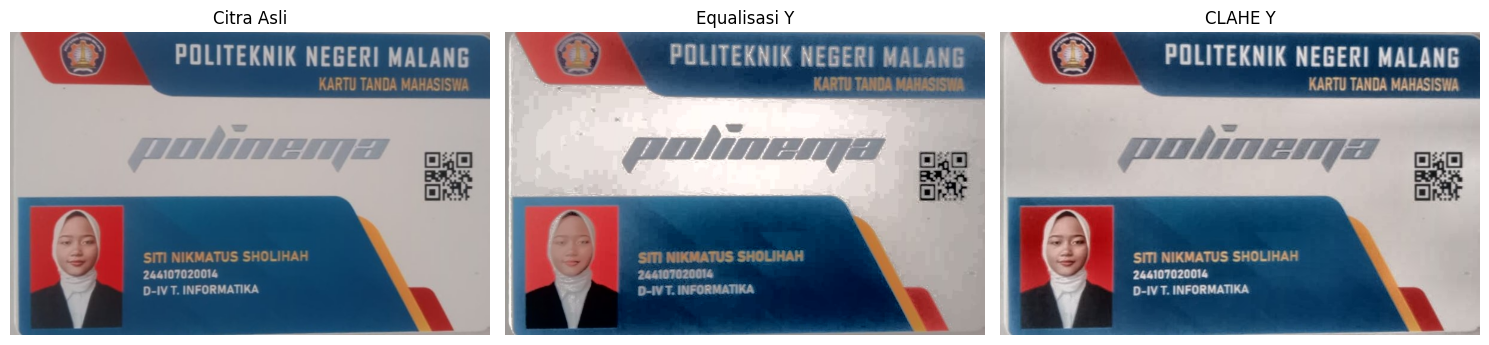

In [59]:
# CLAHE

PARAM = {
    'clip': 2.0,
    'tile': 8
}
clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)

y_clahe = clahe.apply(y)
ho_y_clahe = cv.cvtColor(
    cv.merge([y_clahe, cr, cb]),
    cv.COLOR_YCrCb2BGR
)

# PERBANDINGAN CLAHE

hue_y_clahe = hitung_hue_shift(bgr, ho_y_clahe)
cerah_y_clahe = rata_kecerahan(ho_y_clahe)

print('Equalisasi Y')
print('Hue       :', hue_y)
print('Kecerahan :', cerah_y)
print('\nCLAHE Y')
print('Hue       :', hue_y_clahe)
print('Kecerahan :', cerah_y_clahe)

# TAMPILKAN HASIL

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(ho_y, cv.COLOR_BGR2RGB))
plt.title('Equalisasi Y')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(ho_y_clahe, cv.COLOR_BGR2RGB))
plt.title('CLAHE Y')
plt.axis('off')
plt.tight_layout()
plt.show()

Catat hasilnya pada tabel berikut.

| Cara ekualisasi | Rata-rata pergeseran Hue (derajat) | Rerata kecerahan sesudah | Catatan pengamatan visual |
|---|---:|---:|---|
| Citra asli | - | 149,97 | Citra asli |
| Ekualisasi kanal B, G, R | 27,54 | 150,58 | Warna mengalami perubahan cukup terlihat |
| Kanal Y (YCrCb) | 0,61 | 156,11 | Kontras meningkat dan warna relatif tetap |
| Kanal V (HSV) | 0,90 | 130,05 | Citra menjadi lebih gelap, warna relatif tetap |
| Kanal L (LAB) | 1,82 | 148,31 | Kontras meningkat, warna relatif tetap |

Berdasarkan hasil pengukuran, equalization kanal B, G, R menghasilkan rata-rata pergeseran Hue paling besar, yaitu 27,54 derajat. Hal ini menunjukkan bahwa melakukan equalization secara terpisah pada setiap kanal warna dapat menyebabkan perubahan warna yang lebih besar dibandingkan equalization pada kanal kecerahan saja.

**Jawab pertanyaan berikut berdasarkan angka pada tabel Anda, bukan hanya dari pengamatan mata:**

1. Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada citra Anda?

**Jawab :**


Cara yang menghasilkan pergeseran Hue paling besar adalah ekualisasi kanal B, G, R, yaitu sebesar 27,54 derajat. Nilai ini jauh lebih besar dibandingkan kanal Y sebesar 0,61°, kanal V sebesar 0,90°, dan kanal L sebesar 1,82°. Hal ini menunjukkan bahwa ekualisasi setiap kanal warna secara terpisah menyebabkan perubahan warna yang lebih besar.


---


2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis nol? Kaitkan jawaban Anda dengan pembulatan dan pemotongan nilai ketika citra dikembalikan ke ruang warna BGR.

**Jawab :**


Ekualisasi pada kanal terang seperti Y, V, dan L hanya mengubah komponen kecerahan, sehingga secara teori komponen warna seharusnya tetap. Namun, setelah proses ekualisasi, citra dikembalikan ke ruang warna BGR melalui proses konversi. Pada proses tersebut terjadi pembulatan dan pemotongan (clipping) nilai piksel ke rentang yang valid, yaitu 0–255. Perubahan kecil akibat pembulatan dan pemotongan tersebut dapat menyebabkan nilai B, G, dan R berubah sedikit. Ketika citra BGR tersebut dikonversi kembali ke HSV untuk menghitung Hue, perubahan kecil pada RGB tersebut dapat menghasilkan pergeseran Hue yang tidak persis nol.

---


3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? Sebutkan alasannya dan tunjukkan bagian citra yang menjadi dasar penilaian.

**Jawab :**

Berdasarkan hasil pengukuran pada citra KTM1d, kanal Y pada ruang warna YCrCb paling sesuai digunakan untuk ekualisasi. Kanal Y menghasilkan rata-rata pergeseran Hue sebesar 0,61°, yang merupakan nilai paling kecil dibandingkan kanal V sebesar 0,90° dan kanal L sebesar 1,82°. Selain itu, kanal Y menghasilkan rerata kecerahan sebesar 156,11, lebih tinggi dibandingkan kanal V sebesar 130,05 dan kanal L sebesar 148,31. Dasar penilaian visualnya adalah bagian objek utama pada foto KTM, terutama area yang menjadi objek pengamatan utama, yang dapat dibandingkan antara citra asli dan hasil ekualisasi kanal Y. Hasil kanal Y meningkatkan kecerahan/kontras dengan perubahan warna yang relatif kecil.

---


4. Ulangi salah satu cara pada kanal terang dengan mengganti cv.equalizeHist menjadi CLAHE yang memakai clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan pergeseran Hue dan rerata kecerahannya dengan hasil ekualisasi biasa

**Jawab :**

Pada ekualisasi biasa kanal Y, rata-rata pergeseran Hue sebesar 0,61° dengan rerata kecerahan 156,11. Setelah menggunakan CLAHE dengan clipLimit = 2.0 dan tileGridSize = (8,8), diperoleh rata-rata pergeseran Hue sebesar 0,0043° dengan rerata kecerahan 153,06.

Hasil tersebut menunjukkan bahwa CLAHE menghasilkan pergeseran Hue yang jauh lebih kecil dibandingkan ekualisasi biasa, yaitu turun dari 0,61° menjadi 0,0043°. Rerata kecerahan CLAHE juga sedikit lebih rendah, yaitu 153,06 dibandingkan 156,11 pada ekualisasi biasa. Jadi, pada citra KTM1d, CLAHE memberikan perubahan warna yang lebih kecil dengan tingkat kecerahan yang sedikit lebih rendah.

---



**PERTANYAAN PRAKTIKUM E2**

1. Ekualisasi global pada citra KTM Anda

a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi
grayscale.

b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.

c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai
PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR
layak dipakai untuk menilai keterbacaan sebuah citra.




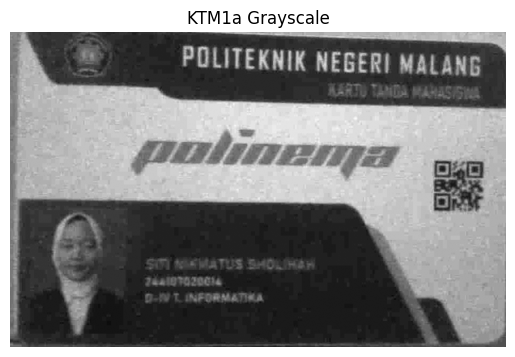

Selisih maksimum manual vs cv.equalizeHist: 0


In [61]:
# 1a. ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi grayscale

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/PVCK/GAMBAR/KTM1a.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title('KTM1a Grayscale')
plt.axis('off')
plt.show()

# HISTOGRAM

height, width = gray.shape
total_pixel = height * width
hist = [0] * 256

for y in range(height):
  for x in range(width):
    hist[gray[y][x]] += 1

# EQUALISASI MANUAL

cdf = np.cumsum(hist)
cdf_normal = cdf / total_pixel
k = np.round(cdf_normal * 255).astype(np.uint8)

# TRANSFORMASI CITRA

hasil_manual = gray.copy()
for y in range(height):
  for x in range(width):
    hasil_manual[y][x] = k[gray[y][x]]

# EQUALISASI OPENCV

hasil_cv = cv.equalizeHist(gray)
selisih = np.max(
    np.abs(
        hasil_manual.astype(np.int16) -
        hasil_cv.astype(np.int16)
    )
)
print('Selisih maksimum manual vs cv.equalizeHist:', selisih)

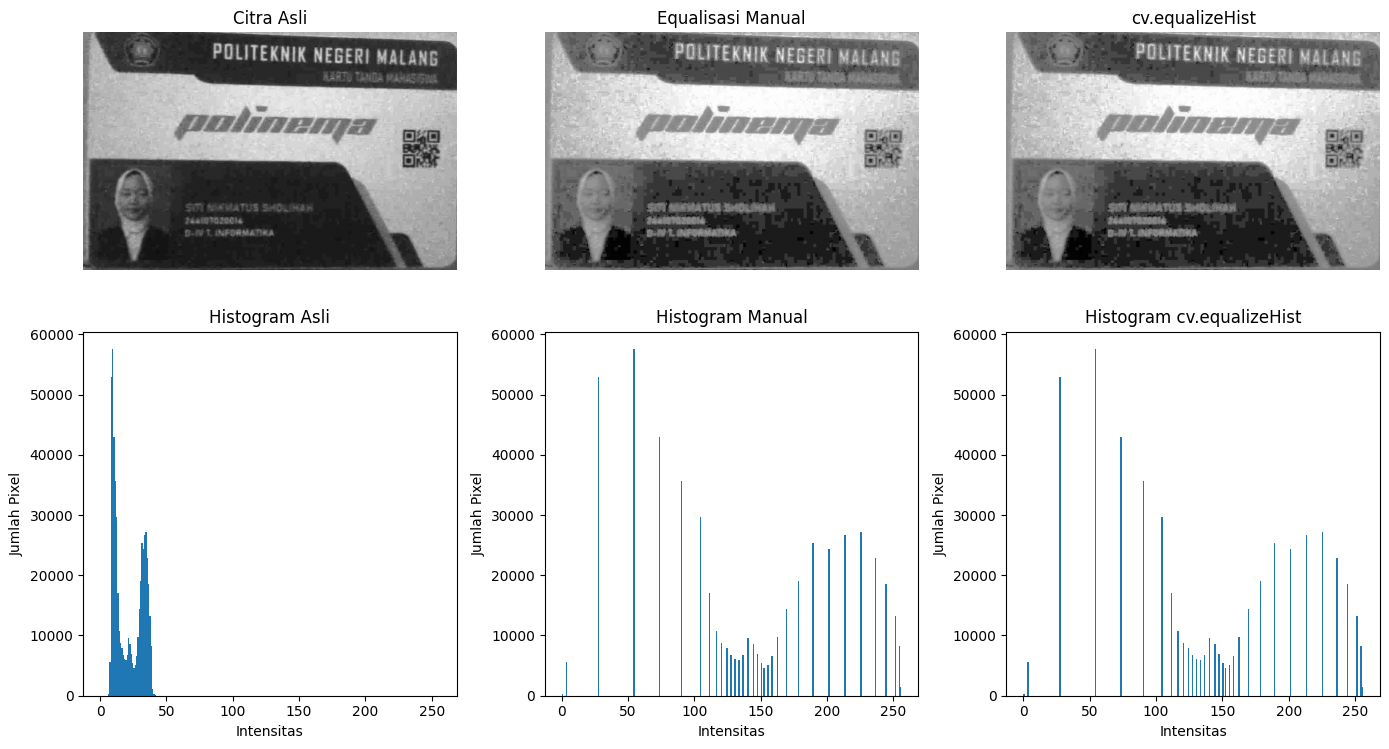

In [62]:
# 1b. citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.

# TAMPILKAN HASIL

plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(hasil_manual, cmap='gray')
plt.title('Equalisasi Manual')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(hasil_cv, cmap='gray')
plt.title('cv.equalizeHist')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.hist(gray.ravel(), bins=256, range=[0, 256])
plt.title('Histogram Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.subplot(2, 3, 5)
plt.hist(hasil_manual.ravel(), bins=256, range=[0, 256])
plt.title('Histogram Manual')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.subplot(2, 3, 6)
plt.hist(hasil_cv.ravel(), bins=256, range=[0, 256])
plt.title('Histogram cv.equalizeHist')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

In [63]:
# 1c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai
# PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR
# layak dipakai untuk menilai keterbacaan sebuah citra.

# PSNR

mse_manual = np.mean(
    (gray.astype(np.float64) -
     hasil_manual.astype(np.float64)) ** 2
)
mse_cv = np.mean(
    (gray.astype(np.float64) -
     hasil_cv.astype(np.float64)) ** 2
)
psnr_manual = 10 * np.log10((255 ** 2) / mse_manual)
psnr_cv = 10 * np.log10((255 ** 2) / mse_cv)

print('PSNR Manual       :', psnr_manual, 'dB')
print('PSNR cv.equalizeHist :', psnr_cv, 'dB')

#

PSNR Manual       : 5.944554394543595 dB
PSNR cv.equalizeHist : 5.944554394543595 dB


2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda

a. Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan
tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi
global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?

b. Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang
noise-nya mulai menonjol ketika clipLimit dinaikkan.

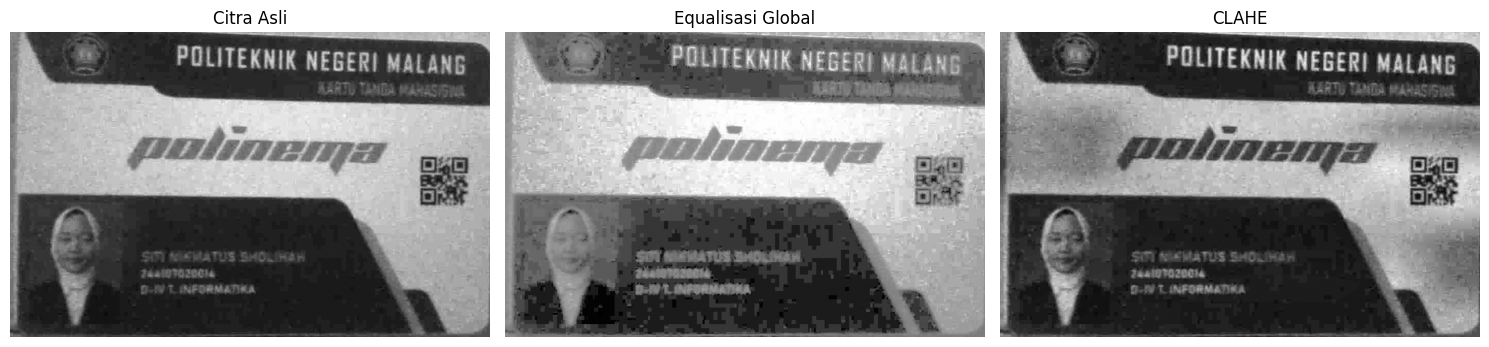

In [64]:
# 2a.

# PARAMETER CLAHE

PARAM = {
    'clip': 2.0,
    'tile': 8
}

# CLAHE

clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)
hasil_clahe = clahe.apply(gray)

# TAMPILKAN HASIL

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(hasil_cv, cmap='gray')
plt.title('Equalisasi Global')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hasil_clahe, cmap='gray')
plt.title('CLAHE')
plt.axis('off')

plt.tight_layout()
plt.show()

Pada citra KTM1a, hasil CLAHE lebih baik dalam mempertahankan keterbacaan NIM dan nama dibandingkan ekualisasi global. Pada ekualisasi global, kontras memang meningkat, tetapi bagian kartu terutama area foto dan tulisan mengalami noise yang lebih terlihat. Sementara itu, CLAHE menghasilkan peningkatan kontras yang lebih merata sehingga tulisan nama dan NIM masih terlihat lebih jelas dengan noise yang lebih terkendali.

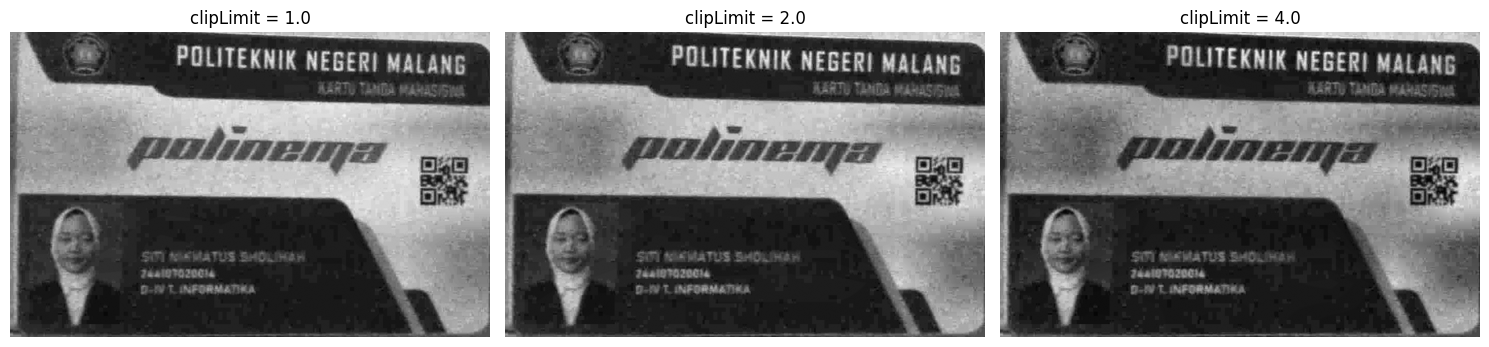

In [65]:
# 2b.

# PERBANDINGAN CLIPLIMIT

clip_values = [1.0, 2.0, 4.0]
plt.figure(figsize=(15, 5))

for i, clip in enumerate(clip_values):
  clahe = cv.createCLAHE(
      clipLimit=clip,
      tileGridSize=(PARAM['tile'], PARAM['tile'])
  )

  hasil = clahe.apply(gray)

  plt.subplot(1, 3, i + 1)
  plt.imshow(hasil, cmap='gray')
  plt.title('clipLimit = ' + str(clip))
  plt.axis('off')

plt.tight_layout()
plt.show()

Pada percobaan digunakan tiga nilai clipLimit, yaitu 1.0, 2.0, dan 4.0. Berdasarkan hasil visual, clipLimit = 2.0 memberikan hasil yang paling seimbang karena kontras citra meningkat dan tulisan pada kartu masih terlihat cukup jelas tanpa terlalu banyak noise.

Pada clipLimit = 1.0, peningkatan kontras terlihat lebih rendah sehingga beberapa detail tulisan masih kurang menonjol. Pada clipLimit = 4.0, kontras lokal semakin kuat dan noise mulai lebih terlihat, terutama pada bagian area putih/abu-abu di sekitar logo Polinema dan bagian latar kartu. Ketika clipLimit dinaikkan, detail kecil dan noise pada citra ikut semakin diperkuat.

**E-3 TUGAS PRAKTIKUM DITHERING**

1. Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi pada KTM1b.jpg dengan jumlah level PARAM['L'].

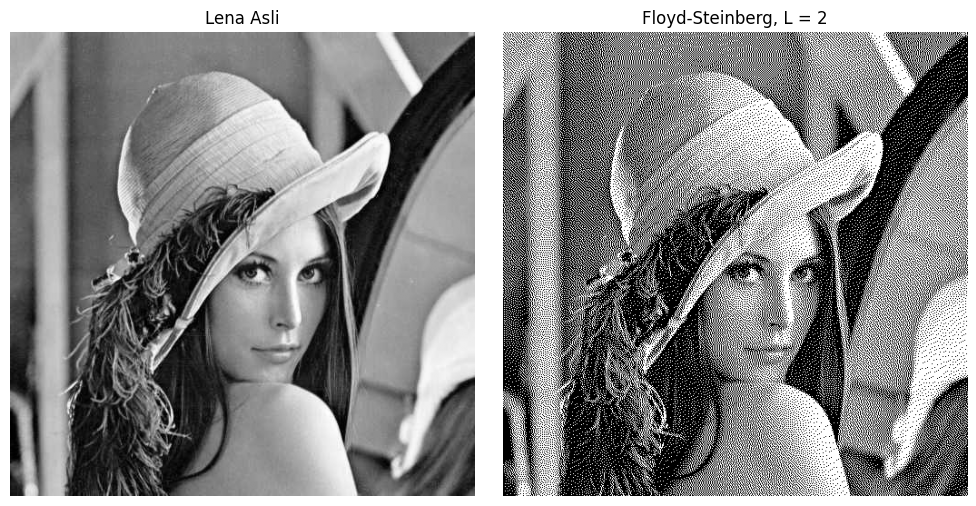

In [66]:
# Tahap 1 lena.jpg

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

PARAM = {
    'L': 2
}

# FLOYD-STEINBERG

def floyd_steinberg(gray, L):
    img = gray.astype(np.float64).copy()
    step = 255 / (L - 1)
    height, width = img.shape

    for y in range(height):
        for x in range(width):
            old_pixel = img[y, x]
            new_pixel = np.round(old_pixel / step) * step
            new_pixel = np.clip(new_pixel, 0, 255)
            error = old_pixel - new_pixel
            img[y, x] = new_pixel
            if x + 1 < width:
                img[y, x + 1] += error * 7 / 16
            if y + 1 < height and x - 1 >= 0:
                img[y + 1, x - 1] += error * 3 / 16
            if y + 1 < height:
                img[y + 1, x] += error * 5 / 16
            if y + 1 < height and x + 1 < width:
                img[y + 1, x + 1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

lena = cv.imread(
    '/content/drive/MyDrive/PVCK/GAMBAR/lena.jpg'
)

lena_gray = cv.cvtColor(
    lena,
    cv.COLOR_BGR2GRAY
)

lena_dither = floyd_steinberg(
    lena_gray,
    PARAM['L']
)

# TAMPILKAN HASIL

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(lena_gray, cmap='gray')
plt.title('Lena Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(lena_dither, cmap='gray')
plt.title('Floyd-Steinberg, L = ' + str(PARAM['L']))
plt.axis('off')

plt.tight_layout()
plt.show()

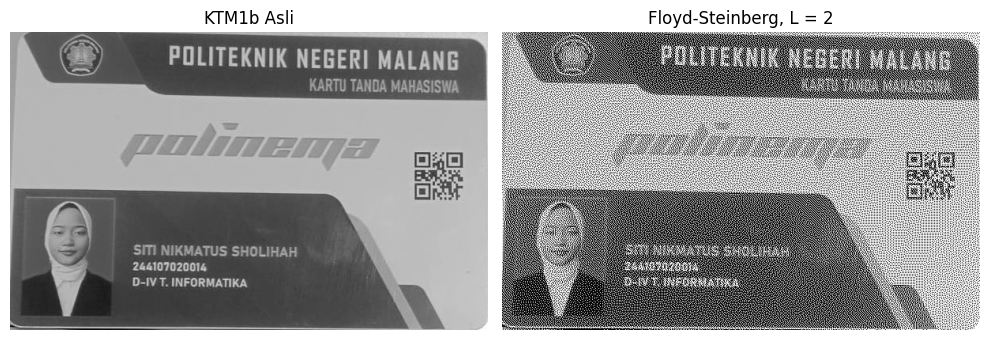

In [67]:
# Tahap 2 KTM1b

ktm = cv.imread(
    '/content/drive/MyDrive/PVCK/GAMBAR/KTM1b.jpg'
)

ktm_gray = cv.cvtColor(
    ktm,
    cv.COLOR_BGR2GRAY
)

ktm_dither = floyd_steinberg(
    ktm_gray,
    PARAM['L']

)

# TAMPILKAN HASIL

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(ktm_gray, cmap='gray')
plt.title('KTM1b Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(ktm_dither, cmap='gray')
plt.title('Floyd-Steinberg, L = ' + str(PARAM['L']))
plt.axis('off')

plt.tight_layout()
plt.show()

2. Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang menghasilkan teks pada KTM lebih terbaca.

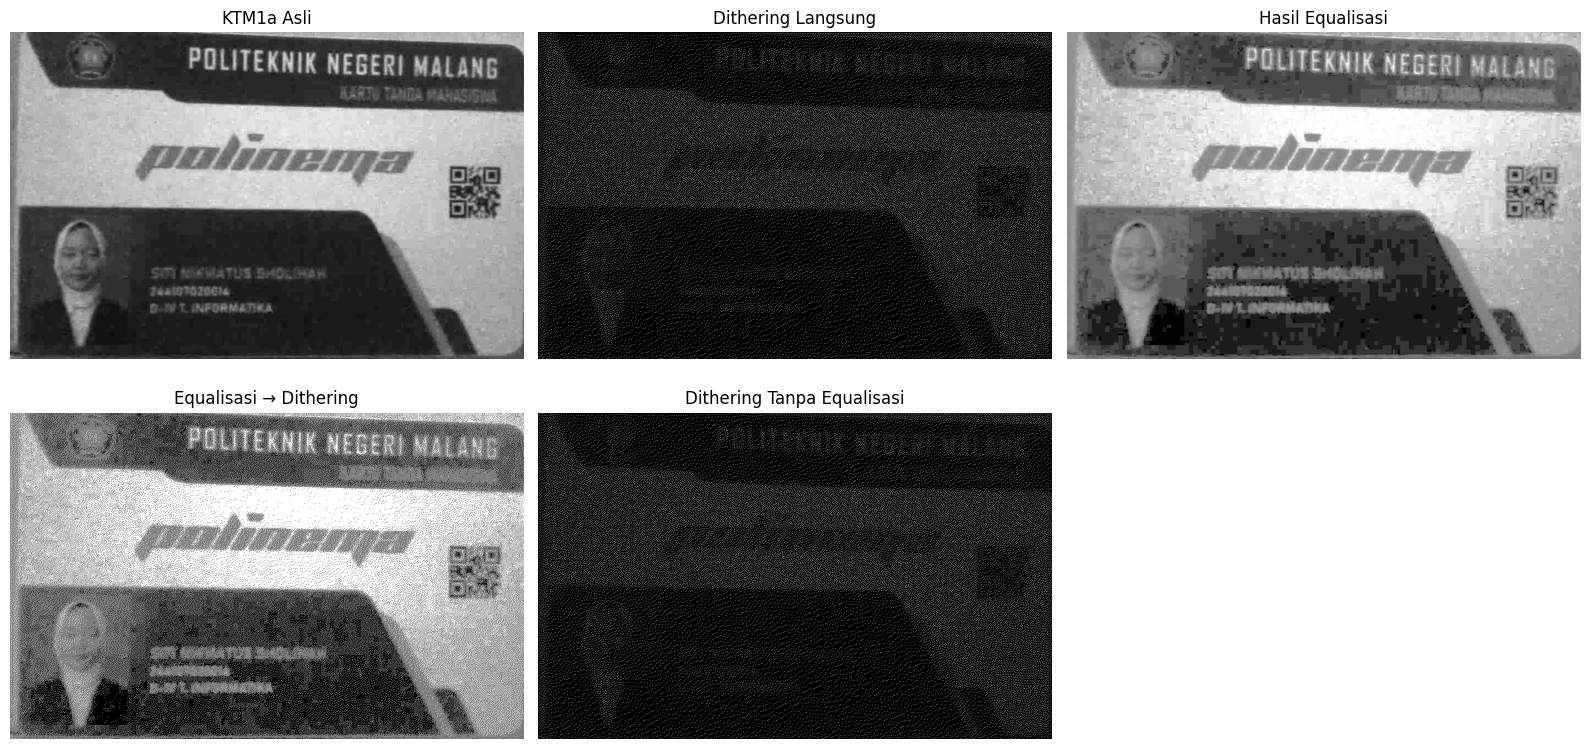

In [68]:
# EQUALISASI

ktm1a = cv.imread(
    '/content/drive/MyDrive/PVCK/GAMBAR/KTM1a.jpg'
)

ktm1a_gray = cv.cvtColor(
    ktm1a,
    cv.COLOR_BGR2GRAY
)

ktm1a_eq = cv.equalizeHist(
    ktm1a_gray
)

# DITHERING HASIL EQUALISASI

ktm_eq_dither = floyd_steinberg(
    ktm1a_eq,
    PARAM['L']
)

# DITHERING LANGSUNG

ktm_direct_dither = floyd_steinberg(
    ktm1a_gray,
    PARAM['L']
)

# TAMPILKAN PERBANDINGAN

plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.imshow(ktm1a_gray, cmap='gray')
plt.title('KTM1a Asli')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(ktm_direct_dither, cmap='gray')
plt.title('Dithering Langsung')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(ktm1a_eq, cmap='gray')
plt.title('Hasil Equalisasi')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(ktm_eq_dither, cmap='gray')
plt.title('Equalisasi → Dithering')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(ktm_direct_dither, cmap='gray')
plt.title('Dithering Tanpa Equalisasi')
plt.axis('off')

plt.tight_layout()
plt.show()